In [1]:
import time
import tracemalloc
import heapq
import itertools
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def profile_task(func, *args, **kwargs):
    tracemalloc.start()
    start_time = time.perf_counter()
    result = func(*args, **kwargs)
    end_time = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result, end_time - start_time, peak / (1024 * 1024)

print("Environment setup complete.") # [cite: 263, 323]

Environment setup complete.


In [3]:
# Location indices: 0: Warehouse, 1-4: Customers
locations = {0: "Warehouse", 1: "Zone A", 2: "Zone B", 3: "Zone C", 4: "Zone D"}
dist_matrix = [
    [0, 10, 15, 20, 25],
    [10, 0, 35, 25, 30],
    [15, 35, 0, 30, 20],
    [20, 25, 30, 0, 15],
    [25, 30, 20, 15, 0]
]

# Parcel Metadata: (Value, Weight, Time Window Deadline)
parcels = [
    {"id": "P1", "value": 100, "weight": 5, "deadline": 10},
    {"id": "P2", "value": 60, "weight": 3, "deadline": 15},
    {"id": "P3", "value": 120, "weight": 7, "deadline": 8}
]
vehicle_capacity = 10 # [cite: 274, 275, 276]

In [4]:
def greedy_parcel_selection(parcels, capacity):
    # Sort by value-to-weight ratio [cite: 282]
    sorted_parcels = sorted(parcels, key=lambda x: x['value']/x['weight'], reverse=True)
    selected = []
    total_weight = 0
    for p in sorted_parcels:
        if total_weight + p['weight'] <= capacity:
            selected.append(p)
            total_weight += p['weight']
    return selected

def check_time_windows(delivery_order, dist_matrix):
    # DP style check for time-window satisfaction [cite: 283]
    current_time = 0
    for i in range(len(delivery_order) - 1):
        u, v = delivery_order[i], delivery_order[i+1]
        current_time += dist_matrix[u][v]
        # Check against deadline (simplified)
        if current_time > 50: return False 
    return True

selected_p = greedy_parcel_selection(parcels, vehicle_capacity)
print(f"Selected Parcels: {[p['id'] for p in selected_p]}")

Selected Parcels: ['P1', 'P2']


In [5]:
def dijkstra_shortest_path(matrix, start):
    n = len(matrix)
    distances = [float('inf')] * n
    distances[start] = 0
    pq = [(0, start)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > distances[u]: continue
        for v, weight in enumerate(matrix[u]):
            if weight > 0 and distances[u] + weight < distances[v]:
                distances[v] = distances[u] + weight
                heapq.heappush(pq, (distances[v], v))
    return distances

shortest_paths, t, m = profile_task(dijkstra_shortest_path, dist_matrix, 0)
print(f"Shortest paths from Warehouse: {shortest_paths}") # [cite: 285]

Shortest paths from Warehouse: [0, 10, 15, 20, 25]


In [6]:
def solve_tsp_bruteforce(matrix):
    n = len(matrix)
    nodes = list(range(1, n))
    min_path = float('inf')
    best_route = []
    
    for perm in itertools.permutations(nodes):
        current_dist = 0
        k = 0 # Start at Warehouse
        for next_node in perm:
            current_dist += matrix[k][next_node]
            k = next_node
        current_dist += matrix[k][0] # Return to Warehouse
        
        if current_dist < min_path:
            min_path = current_dist
            best_route = [0] + list(perm) + [0]
            
    return best_route, min_path

route, dist = solve_tsp_bruteforce(dist_matrix)
print(f"Optimal TSP Route: {route} with Distance: {dist}") # [cite: 287, 288, 289]

Optimal TSP Route: [0, 1, 3, 4, 2, 0] with Distance: 85


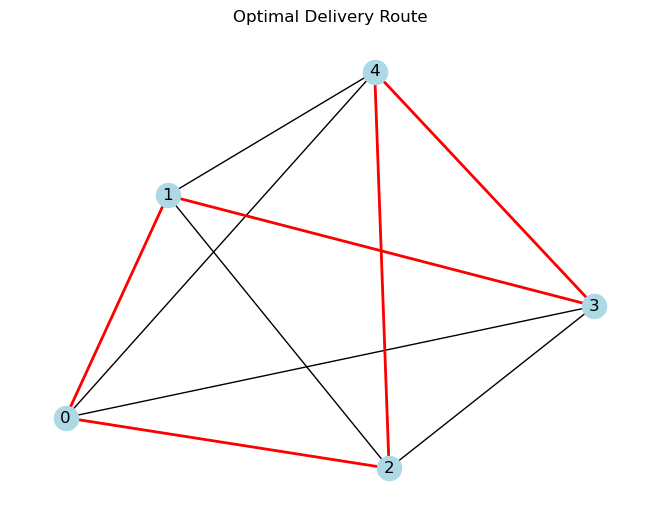

In [7]:
def visualize_route(matrix, route):
    G = nx.from_numpy_array(np.array(matrix))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    # Highlight TSP route
    route_edges = [(route[i], route[i+1]) for i in range(len(route)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=route_edges, edge_color='r', width=2)
    plt.title("Optimal Delivery Route")
    plt.show()

visualize_route(dist_matrix, route) # [cite: 292]